# Slope trajectory

## visualisation in mujuco: slope circle trajectory 

In [2]:
from utils import euler_to_rot_matrix
import numpy as np

In [3]:


# --- INPUT PARAMETERS ---
body_pos = np.array([0.55, 0.0, 0.55])   # Slope body position in world frame
euler = np.array([0.5236, 0, 0])         # Roll, pitch, yaw (rad)
size_z = 0.01                            # Half thickness of box
r = 0.10                                 # Circle radius (m)
num_points = 36                          # Number of points in circle

# --- Step 1: Rotation matrix from euler (X-Y-Z intrinsic order) ---
R = euler_to_rot_matrix(euler)

# --- Step 2: Generate circle points in local slope frame ---
theta = np.linspace(0, 2*np.pi, num_points, endpoint=False)
circle_local = np.zeros((num_points, 3))
circle_local[:, 0] = r * np.cos(theta)  # x
circle_local[:, 1] = r * np.sin(theta)  # y
circle_local[:, 2] = size_z             # z (surface center offset)

# --- Step 3: Transform to world frame ---
circle_world = body_pos + (R @ circle_local.T).T

# --- Step 4: Output MuJoCo site XML ---
print("<!-- Circle sites on slope surface -->")
for i, point in enumerate(circle_world):
    print(f'<site name="circle_{i}" pos="{point[0]:.4f} {point[1]:.4f} {point[2]:.4f}" size="0.003" rgba="0 0 1 1"/>')


<!-- Circle sites on slope surface -->
<site name="circle_0" pos="0.6500 -0.0050 0.5587" size="0.003" rgba="0 0 1 1"/>
<site name="circle_1" pos="0.6485 0.0100 0.5673" size="0.003" rgba="0 0 1 1"/>
<site name="circle_2" pos="0.6440 0.0246 0.5758" size="0.003" rgba="0 0 1 1"/>
<site name="circle_3" pos="0.6366 0.0383 0.5837" size="0.003" rgba="0 0 1 1"/>
<site name="circle_4" pos="0.6266 0.0507 0.5908" size="0.003" rgba="0 0 1 1"/>
<site name="circle_5" pos="0.6143 0.0613 0.5970" size="0.003" rgba="0 0 1 1"/>
<site name="circle_6" pos="0.6000 0.0700 0.6020" size="0.003" rgba="0 0 1 1"/>
<site name="circle_7" pos="0.5842 0.0764 0.6056" size="0.003" rgba="0 0 1 1"/>
<site name="circle_8" pos="0.5674 0.0803 0.6079" size="0.003" rgba="0 0 1 1"/>
<site name="circle_9" pos="0.5500 0.0816 0.6087" size="0.003" rgba="0 0 1 1"/>
<site name="circle_10" pos="0.5326 0.0803 0.6079" size="0.003" rgba="0 0 1 1"/>
<site name="circle_11" pos="0.5158 0.0764 0.6056" size="0.003" rgba="0 0 1 1"/>
<site name

## trajectory generation

In [4]:
# --- INPUT PARAMETERS ---
body_pos = np.array([0.55, 0.0, 0.55])   # Slope body position in world frame
euler = np.array([0.5236, 0, 0])         # Roll, pitch, yaw (rad)
size_z = 0.01                            # Half thickness of box
r = 0.10                                 # Circle radius (m)
num_points = 36                          # Number of points in circle
angular_speed = np.pi/2
delta_t = 0.2
T = (2 * np.pi) / angular_speed
time = np.arange(0, T, delta_t)


In [8]:
circle_points = []
for i, elapsed_time in enumerate(time):
    theta = angular_speed * elapsed_time
    circle_local = np.zeros(3)
    circle_local[0] = r * np.cos(theta)  # x
    circle_local[1] = r * np.sin(theta)  # y
    circle_local[2] = size_z             # z
    circle_points.append(circle_local)

circle_local_array = np.array(circle_points)
# --- Step 3: Transform to world frame ---
circle_world = body_pos + (R @ circle_local_array.T).T
circle_sites = "<!-- Circle sites on slope surface -->\n"
for i, point in enumerate(circle_world):
    circle_sites += (
        f'<site name="circle_{i}" '
        f'pos="{point[0]:.4f} {point[1]:.4f} {point[2]:.4f}" '
        f'size="0.003" rgba="0 0 1 1"/>\n'
    )
# print("<!-- Circle sites on slope surface -->")
# for i, point in enumerate(circle_world):
#     print(f'<site name="circle_{i}" pos="{point[0]:.4f} {point[1]:.4f} {point[2]:.4f}" size="0.003" rgba="0 0 1 1"/>')

In [9]:
circle_sites

'<!-- Circle sites on slope surface -->\n<site name="circle_0" pos="0.6500 -0.0050 0.5587" size="0.003" rgba="0 0 1 1"/>\n<site name="circle_1" pos="0.6451 0.0218 0.5741" size="0.003" rgba="0 0 1 1"/>\n<site name="circle_2" pos="0.6309 0.0459 0.5880" size="0.003" rgba="0 0 1 1"/>\n<site name="circle_3" pos="0.6088 0.0651 0.5991" size="0.003" rgba="0 0 1 1"/>\n<site name="circle_4" pos="0.5809 0.0774 0.6062" size="0.003" rgba="0 0 1 1"/>\n<site name="circle_5" pos="0.5500 0.0816 0.6087" size="0.003" rgba="0 0 1 1"/>\n<site name="circle_6" pos="0.5191 0.0774 0.6062" size="0.003" rgba="0 0 1 1"/>\n<site name="circle_7" pos="0.4912 0.0651 0.5991" size="0.003" rgba="0 0 1 1"/>\n<site name="circle_8" pos="0.4691 0.0459 0.5880" size="0.003" rgba="0 0 1 1"/>\n<site name="circle_9" pos="0.4549 0.0218 0.5741" size="0.003" rgba="0 0 1 1"/>\n<site name="circle_10" pos="0.4500 -0.0050 0.5587" size="0.003" rgba="0 0 1 1"/>\n<site name="circle_11" pos="0.4549 -0.0318 0.5432" size="0.003" rgba="0 0 1 

In [6]:
theta = 0
circle_local = np.zeros(3)
circle_local[0] = r * np.cos(theta)  # x
circle_local[1] = r * np.sin(theta)  # y
circle_local[2] = size_z

In [7]:
body_pos + (R @ circle_local.T).T

array([ 0.65      , -0.00500001,  0.55866025])

In [18]:
R_slope = euler_to_rot_matrix(np.array([0.5236, 0, 0]))
target_pos = np.array([0.6500, -0.0050, 0.5587])
R_slope @ target_pos

array([ 0.65      , -0.28368072,  0.48134805])

In [10]:
np.deg2rad(30)

np.float64(0.5235987755982988)

## Cylinder

In [1]:
from utils import add_cylinder_xml
import numpy as np

In [2]:
xml_path = "kuka_iiwa_14/scene_notable.xml"
euler = np.array([0, np.deg2rad(-90), 0])
circle_center = np.array([0.5, 0.0, 0.45])

In [3]:
add_cylinder_xml(xml_path=xml_path, euler=euler, size=[0.1, 0.1], body_pos=circle_center)

'./kuka_iiwa_14/cylinder_auto.xml'

Sin traj

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
def generate_sinusoidal_trajectory(
    elapsed_time: float,
    start_pos: np.ndarray,
    amplitude: float,
    frequency: float,
    R_slope: np.ndarray,
    size_z: float
):
    """
    Generate desired position, velocity, and acceleration for sinusoidal trajectory.
    
    The trajectory moves in the -x direction (back and forth) with sinusoidal motion.
    Perfect for observing friction effects at velocity reversals.
    
    Args:
        elapsed_time: Elapsed time since start of motion
        start_pos: Starting position (3D position, center of motion)
        amplitude: Amplitude of sinusoidal motion (meters, e.g., 0.04 for ±4cm)
        frequency: Frequency of oscillation (Hz, e.g., 0.5 for slow motion)
        R_slope: Rotation matrix of the slope
        size_z: Height offset on the surface
    
    Returns:
        Tuple of (target_pos, x_dot_desired, x_ddot_desired)
    """
    omega = 2 * np.pi * frequency  # Angular frequency (rad/s)
    
    # Local coordinates (on the slope surface)
    target_pos_local = np.zeros(3)
    x_dot_desired_local = np.zeros(3)
    x_ddot_desired_local = np.zeros(3)
    
    # Position: x(t) = A * sin(ωt)
    # This oscillates between -A and +A in the x direction
    target_pos_local[0] = amplitude * np.sin(omega * elapsed_time)
    target_pos_local[1] = 0.0  # No motion in y
    target_pos_local[2] = size_z  # Keep Z at surface height
    
    # Velocity: ẋ(t) = Aω * cos(ωt)
    x_dot_desired_local[0] = amplitude * omega * np.cos(omega * elapsed_time)
    x_dot_desired_local[1] = 0.0
    x_dot_desired_local[2] = 0.0
    
    # Acceleration: ẍ(t) = -Aω² * sin(ωt)
    x_ddot_desired_local[0] = -amplitude * omega**2 * np.sin(omega * elapsed_time)
    x_ddot_desired_local[1] = 0.0
    x_ddot_desired_local[2] = 0.0
    
    # Transform from local (slope) coordinates to world coordinates
    return (
        start_pos + (R_slope @ target_pos_local),
        R_slope @ x_dot_desired_local,
        R_slope @ x_ddot_desired_local
    )

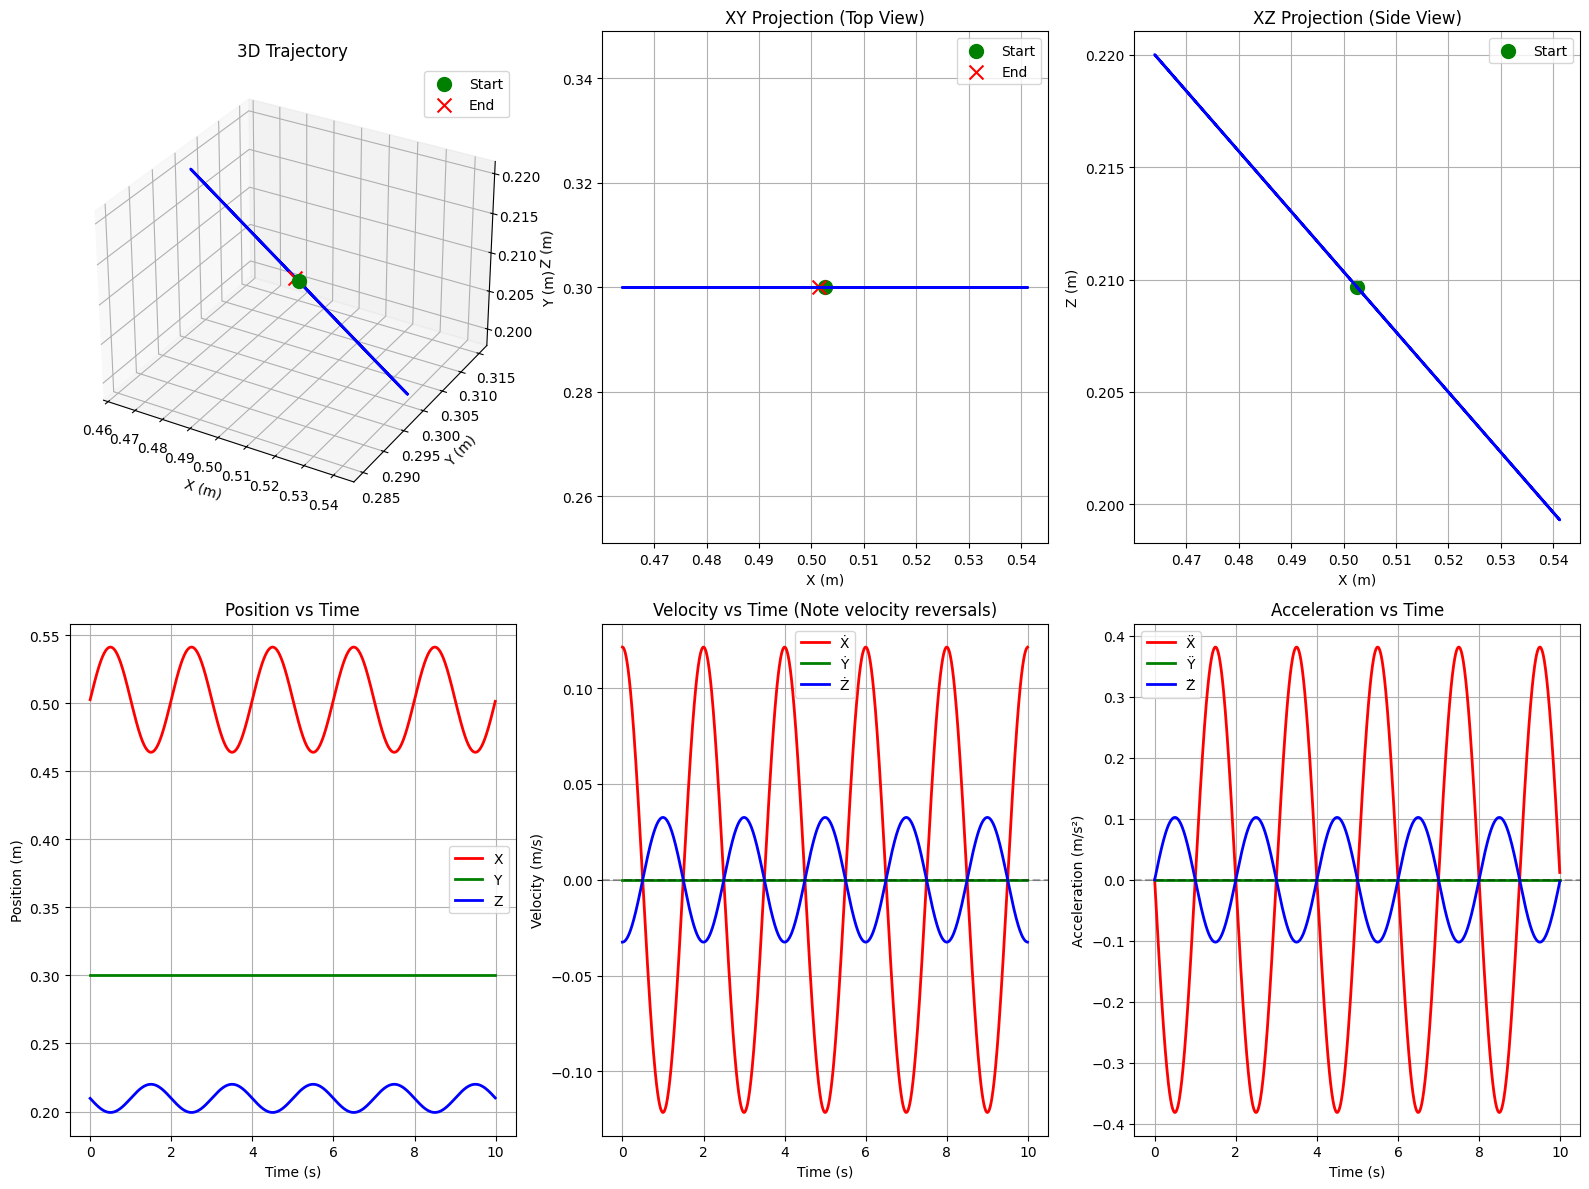


=== Trajectory Statistics ===
Duration: 10.0 seconds
Frequency: 0.5 Hz
Period: 2.00 seconds
Amplitude: 4.0 cm
Total range: 8.0 cm

Position range:
  X: [0.4640, 0.5412] m
  Y: [0.3000, 0.3000] m
  Z: [0.1993, 0.2200] m

Max velocity: 0.1257 m/s
Max acceleration: 0.3948 m/s²

Number of velocity reversals: 10


In [3]:


def plot_sinusoidal_trajectory(
    start_pos: np.ndarray,
    amplitude: float,
    frequency: float,
    R_slope: np.ndarray,
    size_z: float,
    duration: float = 10.0,
    dt: float = 0.01
):
    """
    Plot the sinusoidal trajectory in 3D and various 2D projections.
    
    Args:
        start_pos: Starting position (3D)
        amplitude: Amplitude of sinusoidal motion
        frequency: Frequency of oscillation (Hz)
        R_slope: Rotation matrix of the slope
        size_z: Height offset on the surface
        duration: Total duration to simulate (seconds)
        dt: Time step for plotting
    """
    # Generate trajectory data
    time_array = np.arange(0, duration, dt)
    positions = []
    velocities = []
    accelerations = []
    
    for t in time_array:
        pos, vel, acc = generate_sinusoidal_trajectory(
            elapsed_time=t,
            start_pos=start_pos,
            amplitude=amplitude,
            frequency=frequency,
            R_slope=R_slope,
            size_z=size_z
        )
        positions.append(pos)
        velocities.append(vel)
        accelerations.append(acc)
    
    positions = np.array(positions)
    velocities = np.array(velocities)
    accelerations = np.array(accelerations)
    
    # Create figure with multiple subplots
    fig = plt.figure(figsize=(16, 12))
    
    # 1. 3D Trajectory
    ax1 = fig.add_subplot(2, 3, 1, projection='3d')
    ax1.plot(positions[:, 0], positions[:, 1], positions[:, 2], 'b-', linewidth=2)
    ax1.scatter(positions[0, 0], positions[0, 1], positions[0, 2], 
                c='g', s=100, marker='o', label='Start')
    ax1.scatter(positions[-1, 0], positions[-1, 1], positions[-1, 2], 
                c='r', s=100, marker='x', label='End')
    ax1.set_xlabel('X (m)')
    ax1.set_ylabel('Y (m)')
    ax1.set_zlabel('Z (m)')
    ax1.set_title('3D Trajectory')
    ax1.legend()
    ax1.grid(True)
    
    # 2. XY Projection (Top view)
    ax2 = fig.add_subplot(2, 3, 2)
    ax2.plot(positions[:, 0], positions[:, 1], 'b-', linewidth=2)
    ax2.scatter(positions[0, 0], positions[0, 1], c='g', s=100, marker='o', label='Start')
    ax2.scatter(positions[-1, 0], positions[-1, 1], c='r', s=100, marker='x', label='End')
    ax2.set_xlabel('X (m)')
    ax2.set_ylabel('Y (m)')
    ax2.set_title('XY Projection (Top View)')
    ax2.grid(True)
    ax2.axis('equal')
    ax2.legend()
    
    # 3. XZ Projection (Side view)
    ax3 = fig.add_subplot(2, 3, 3)
    ax3.plot(positions[:, 0], positions[:, 2], 'b-', linewidth=2)
    ax3.scatter(positions[0, 0], positions[0, 2], c='g', s=100, marker='o', label='Start')
    ax3.set_xlabel('X (m)')
    ax3.set_ylabel('Z (m)')
    ax3.set_title('XZ Projection (Side View)')
    ax3.grid(True)
    ax3.legend()
    
    # 4. Position vs Time
    ax4 = fig.add_subplot(2, 3, 4)
    ax4.plot(time_array, positions[:, 0], 'r-', label='X', linewidth=2)
    ax4.plot(time_array, positions[:, 1], 'g-', label='Y', linewidth=2)
    ax4.plot(time_array, positions[:, 2], 'b-', label='Z', linewidth=2)
    ax4.set_xlabel('Time (s)')
    ax4.set_ylabel('Position (m)')
    ax4.set_title('Position vs Time')
    ax4.grid(True)
    ax4.legend()
    
    # 5. Velocity vs Time
    ax5 = fig.add_subplot(2, 3, 5)
    ax5.plot(time_array, velocities[:, 0], 'r-', label='Ẋ', linewidth=2)
    ax5.plot(time_array, velocities[:, 1], 'g-', label='Ẏ', linewidth=2)
    ax5.plot(time_array, velocities[:, 2], 'b-', label='Ż', linewidth=2)
    ax5.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax5.set_xlabel('Time (s)')
    ax5.set_ylabel('Velocity (m/s)')
    ax5.set_title('Velocity vs Time (Note velocity reversals)')
    ax5.grid(True)
    ax5.legend()
    
    # 6. Acceleration vs Time
    ax6 = fig.add_subplot(2, 3, 6)
    ax6.plot(time_array, accelerations[:, 0], 'r-', label='Ẍ', linewidth=2)
    ax6.plot(time_array, accelerations[:, 1], 'g-', label='Ÿ', linewidth=2)
    ax6.plot(time_array, accelerations[:, 2], 'b-', label='Z̈', linewidth=2)
    ax6.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax6.set_xlabel('Time (s)')
    ax6.set_ylabel('Acceleration (m/s²)')
    ax6.set_title('Acceleration vs Time')
    ax6.grid(True)
    ax6.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print trajectory statistics
    print("\n=== Trajectory Statistics ===")
    print(f"Duration: {duration} seconds")
    print(f"Frequency: {frequency} Hz")
    print(f"Period: {1/frequency:.2f} seconds")
    print(f"Amplitude: {amplitude*100:.1f} cm")
    print(f"Total range: {2*amplitude*100:.1f} cm")
    print(f"\nPosition range:")
    print(f"  X: [{positions[:, 0].min():.4f}, {positions[:, 0].max():.4f}] m")
    print(f"  Y: [{positions[:, 1].min():.4f}, {positions[:, 1].max():.4f}] m")
    print(f"  Z: [{positions[:, 2].min():.4f}, {positions[:, 2].max():.4f}] m")
    print(f"\nMax velocity: {np.linalg.norm(velocities, axis=1).max():.4f} m/s")
    print(f"Max acceleration: {np.linalg.norm(accelerations, axis=1).max():.4f} m/s²")
    print(f"\nNumber of velocity reversals: {np.sum(np.diff(np.sign(velocities[:, 0])) != 0)}")


# Example usage
if __name__ == "__main__":
    # Define your parameters
    start_pos = np.array([0.5, 0.3, 0.2])  # Example starting position
    amplitude = 0.04  # 4 cm amplitude
    frequency = 0.5   # 0.5 Hz
    size_z = 0.01     # 1 cm above surface
    
    # Rotation matrix for slope (example: 15 degree tilt around Y axis)
    angle = np.radians(15)
    R_slope = np.array([
        [np.cos(angle), 0, np.sin(angle)],
        [0, 1, 0],
        [-np.sin(angle), 0, np.cos(angle)]
    ])
    
    # Or for flat surface (no rotation)
    # R_slope = np.eye(3)
    
    # Plot the trajectory
    plot_sinusoidal_trajectory(
        start_pos=start_pos,
        amplitude=amplitude,
        frequency=frequency,
        R_slope=R_slope,
        size_z=size_z,
        duration=10.0,  # 10 seconds
        dt=0.01         # 10ms time step
    )